Boston House Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [7]:
df = pd.read_csv('boston.csv')
df  

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [12]:
df.rename(columns={
    'CRIM': 'crime_rate',
    'ZN': 'residential_land_ratio',
    'INDUS': 'non_retail_business_ratio',
    'CHAS': 'near_charles_river',
    'NOX': 'nitric_oxide_concentration',
    'RM': 'avg_rooms_per_dwelling',
    'AGE': 'old_houses_ratio',
    'DIS': 'distance_to_employment_centers',
    'RAD': 'highway_accessibility_index',
    'TAX': 'property_tax_rate',
    'PTRATIO': 'pupil_teacher_ratio',
    'B': 'black_population_index',
    'LSTAT': 'lower_status_population_pct',
    'MEDV': 'median_home_value'
}, inplace=True)

In [13]:
df

,crime_rate,residential_land_ratio,non_retail_business_ratio,near_charles_river,nitric_oxide_concentration,avg_rooms_per_dwelling,old_houses_ratio,distance_to_employment_centers,highway_accessibility_index,property_tax_rate,pupil_teacher_ratio,black_population_index,lower_status_population_pct,median_home_value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## Column Descriptions

| Column | Description |
|----------|----------|
| **crime_rate** | Per capita crime rate by town |
| **residential_land_ratio** | Percentage of residential land zoned for large lots (>25,000 sq.ft.) |
| **non_retail_business_ratio** | Percentage of non-retail business acres per town |
| **near_charles_river** | 1 if tract borders the Charles River, 0 otherwise |
| **nitric_oxide_concentration** | Nitric oxide (NOx) concentration (parts per 10 million) |
| **avg_rooms_per_dwelling** | Average number of rooms per dwelling |
| **old_houses_ratio** | Percentage of owner-occupied homes built before 1940 |
| **distance_to_employment_centers** | Weighted distance to five Boston employment centers |
| **highway_accessibility_index** | Accessibility index to radial highways |
| **property_tax_rate** | Full-value property tax rate per $10,000 |
| **pupil_teacher_ratio** | Student-to-teacher ratio by town |
| **black_population_index** | Calculated as 1000(Bk − 0.63)², where Bk is the proportion of Black residents by town |
| **lower_status_population_pct** | Percentage of lower socioeconomic status population |
| **median_home_value** | Median value of owner-occupied homes (target variable, in $1000s) |

In [ ]:
df.shape # (rows, columns)

(506, 14)

In [17]:
df.isnull().sum()

crime_rate                        0
residential_land_ratio            0
non_retail_business_ratio         0
near_charles_river                0
nitric_oxide_concentration        0
avg_rooms_per_dwelling            0
old_houses_ratio                  0
distance_to_employment_centers    0
highway_accessibility_index       0
property_tax_rate                 0
pupil_teacher_ratio               0
black_population_index            0
lower_status_population_pct       0
median_home_value                 0
dtype: int64

In [18]:
df.describe()

,crime_rate,residential_land_ratio,non_retail_business_ratio,near_charles_river,nitric_oxide_concentration,avg_rooms_per_dwelling,old_houses_ratio,distance_to_employment_centers,highway_accessibility_index,property_tax_rate,pupil_teacher_ratio,black_population_index,lower_status_population_pct,median_home_value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: >

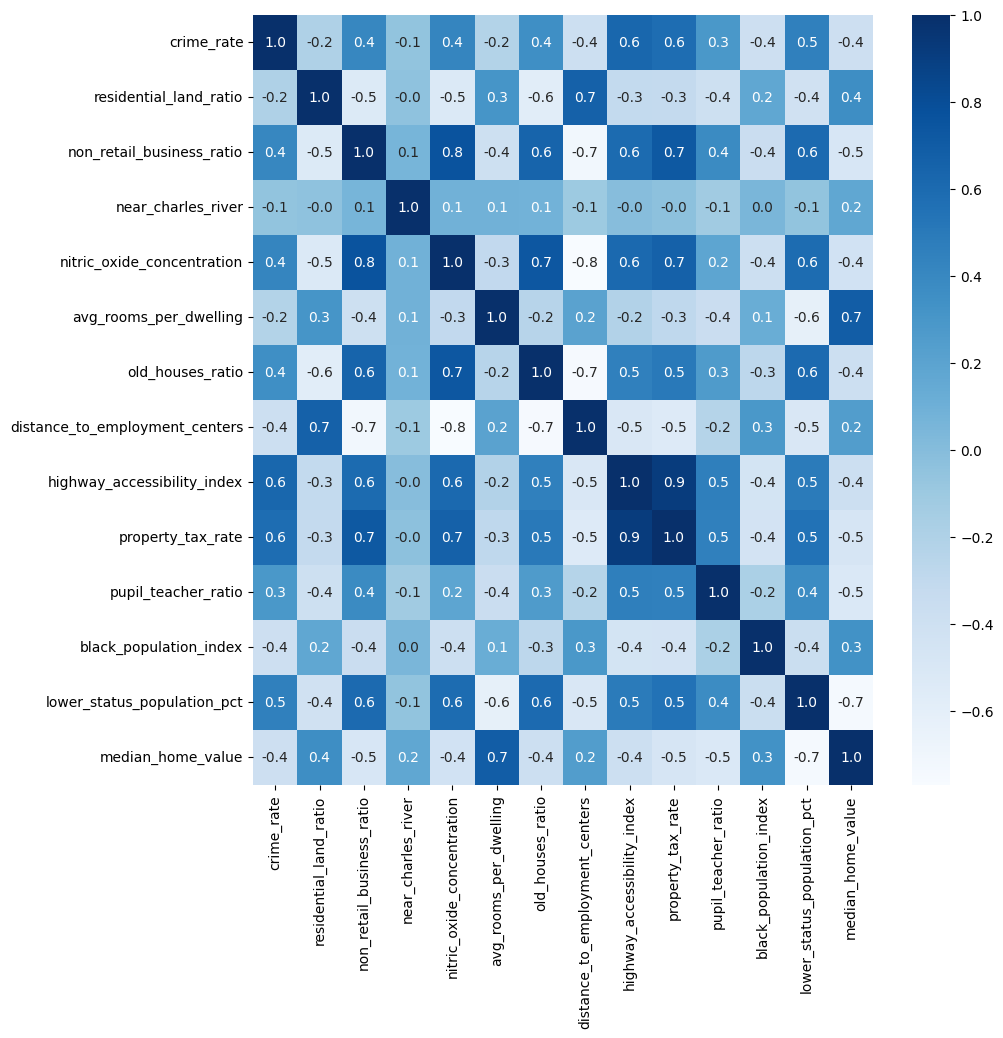

In [33]:
# HeatMap to understand the correlation between the features in the dataset
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='Blues')

In [36]:
X = df.drop(['median_home_value'], axis=1)
Y = df['median_home_value']

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 2)

||   XGBoost Regression   ||

In [39]:
xgbr = XGBRegressor()
xgbr.fit(X_train, Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [48]:
pred_XGB = xgbr.predict(X_test)

In [55]:
R2_score_XGB = metrics.r2_score(Y_test, pred_XGB)
print('R2 Score (XGBRegressor): ', R2_score_XGB)
MAE_XGB = metrics.mean_absolute_error(Y_test, pred_XGB)
print('MAE (XGBRegressor): ', MAE_XGB)
MSE_XGB = metrics.mean_squared_error(Y_test, pred_XGB)
print('MSE (XGBRegressor): ', MSE_XGB)
RMSE_XGB = np.sqrt(metrics.mean_squared_error(Y_test, pred_XGB))
print('RMSE (XGBRegressor): ', RMSE_XGB)

R2 Score (XGBRegressor):  0.9051721149855378
MAE (XGBRegressor):  2.0748727686264927
MSE (XGBRegressor):  7.9332706911154185
RMSE (XGBRegressor):  2.8166062364333815


In [60]:
comparison_df = pd.DataFrame({
    'Actual': Y_test,
    'Predicted_XGB': pred_XGB 
})

comparison_df.head(10)

,Actual,Predicted_XGB
463,20.2,22.007828
152,15.3,21.225981
291,37.3,30.466019
183,32.5,27.735027
384,8.8,9.134951
141,14.4,12.740403
240,22.0,25.738058
349,26.6,27.750889
410,15.0,25.364376
150,21.5,20.229292


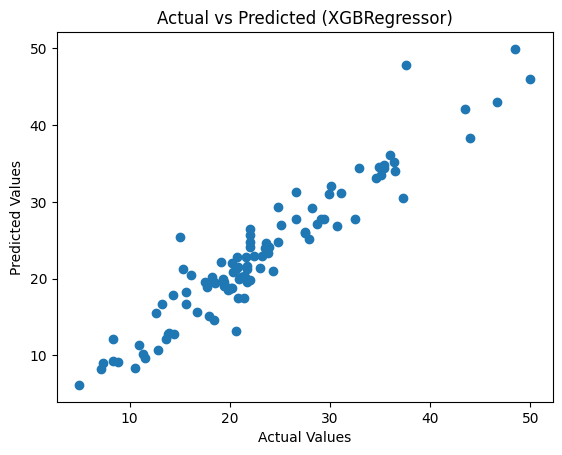

In [53]:
plt.scatter(Y_test, pred_XGB)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (XGBRegressor)')
plt.show()


||  Random Forest Regression  ||

In [46]:
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor()

In [47]:
regr.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [54]:
pred_RF = regr.predict(X_test)

In [61]:
R2_score_RF = metrics.r2_score(Y_test, pred_RF)
print('R2 Score (RandomForestRegressor): ', R2_score_RF)
MAE_RF = metrics.mean_absolute_error(Y_test, pred_RF)
print('MAE (RandomForestRegressor): ', MAE_RF)
MSE_RF = metrics.mean_squared_error(Y_test, pred_RF)
print('MSE (RandomForestRegressor): ', MSE_RF)
RMSE_RF = np.sqrt(metrics.mean_squared_error(Y_test, pred_RF))
print('RMSE (RandomForestRegressor): ', RMSE_RF)

R2 Score (RandomForestRegressor):  0.8793785897771305
MAE (RandomForestRegressor):  2.2217647058823524
MSE (RandomForestRegressor):  10.091148803921564
RMSE (RandomForestRegressor):  3.17665685964373


||  LinearRegression  ||

In [62]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [63]:
reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
reg.score(X_test, Y_test)


0.7789207451814414